<a href="https://colab.research.google.com/github/ommalewar8154-wq/DAA-Project/blob/main/BrainTumorCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Brain Tumor Classification using CNN**

Import Required Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import kagglehub

Load Dataset

In [ ]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

train_dir = os.path.join(path, "Training")
test_dir = os.path.join(path, "Testing")

print("Training Path:", train_dir)
print("Testing Path:", test_dir)

100%|██████████| 157M/157M [00:00<00:00, 189MB/s]

Extracting files...


Training Path: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training
Testing Path: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Testing


Image Preprocessing & Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


 Build CNN Model (Old)

In [ ]:
model = Sequential()

# 32: No. of Filters
# 3*3: Filter size
# ReLU: Remove Negative Values

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
# MaxPooling: Reduces size of images

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
# Converts 2D to 1D
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
#50% randomly disables neurons
model.add(Dropout(0.5))

# 4 Tumour Classes
# Output Layer (4 tumor classes)
model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 720s 4s/step - accuracy: 0.4637 - loss: 1.2709 - val_accuracy: 0.6725 - val_loss: 0.9743
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 716s 4s/step - accuracy: 0.7194 - loss: 0.7079 - val_accuracy: 0.7256 - val_loss: 0.9208
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 716s 4s/step - accuracy: 0.7458 - loss: 0.6346 - val_accuracy: 0.7237 - val_loss: 0.9302
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 743s 4s/step - accuracy: 0.7903 - loss: 0.5354 - val_accuracy: 0.6975 - val_loss: 1.1311
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.8124 - loss: 0.4753 - val_accuracy: 0.7219 - val_loss: 1.0401
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 728s 4s/step - accuracy: 0.8172 - loss: 0.4681 - val_accuracy: 0.7456 - val_loss: 1.1074
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 712s 4s/step - accuracy: 0.8299 - loss: 0.4392 - val_accuracy: 0.7569 - val_loss: 0.9220
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 743s 4s/step - accuracy: 0.8404 - loss: 0.4241 - val_accu

Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7884 - loss: 0.8979
Test Accuracy: 0.7825000286102295


Plot Accuracy Graph

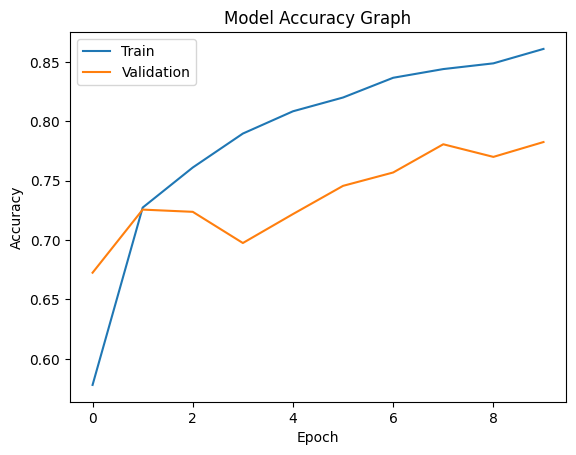

In [ ]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Model Accuracy Graph")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

Plot Loss Graph

In [ ]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Model Loss Graph")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

NameError: name 'plt' is not defined